In [1]:
# importing libraries needed for cleaning and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# uploading the file in colab
from google.colab import files
uploaded = files.upload()

Saving Sales_data.csv to Sales_data.csv


In [3]:
# reading the csv file
df = pd.read_csv('Sales_data.csv')
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,order_id,line_item,order_date,delivery_date,Customer_id,store_id,product_id,Quantity,currency_code,order_year,Has_Order_Date,Order_Month,Delivery_Status,delivery_days,is_store_order,Date_Validity_Check
0,366000,1,01-01-2016,NaN,265598,10,1304,1,CAD,2016,Yes,Jan-2016,Not Recorded,NaN,In-Store,OK
1,366001,1,01-01-2016,13-01-2016,1269051,0,1048,2,USD,2016,Yes,Jan-2016,Delivered,12.0,Online,OK
2,366001,2,01-01-2016,13-01-2016,1269051,0,2007,1,USD,2016,Yes,Jan-2016,Delivered,12.0,Online,OK
3,366002,1,01-01-2016,01-12-2016,266019,0,1106,7,CAD,2016,Yes,Jan-2016,Delivered,335.0,Online,OK
4,366002,2,01-01-2016,01-12-2016,266019,0,373,1,CAD,2016,Yes,Jan-2016,Delivered,335.0,Online,OK


In [4]:
# checking shape and column info
print(df.shape)
df.info()

(62884, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62884 entries, 0 to 62883
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             62884 non-null  int64  
 1   line_item            62884 non-null  int64  
 2   order_date           24344 non-null  object 
 3   delivery_date        13165 non-null  object 
 4   Customer_id          62884 non-null  int64  
 5   store_id             62884 non-null  int64  
 6   product_id           62884 non-null  int64  
 7   Quantity             62884 non-null  int64  
 8   currency_code        62884 non-null  object 
 9   order_year           62884 non-null  object 
 10  Has_Order_Date       62884 non-null  object 
 11  Order_Month          62884 non-null  object 
 12  Delivery_Status      62884 non-null  object 
 13  delivery_days        5178 non-null   float64
 14  is_store_order       62884 non-null  object 
 15  Date_Validity_Check  628

In [5]:
# checking null values in every column
df.isnull().sum()

,0
order_id,0
line_item,0
order_date,38540
delivery_date,49719
Customer_id,0
store_id,0
product_id,0
Quantity,0
currency_code,0
order_year,0


In [6]:
# checking duplicate rows
df.duplicated().sum()

np.int64(0)

In [7]:
# checking duplicate order_id and line_item together
# since one order can have multiple products, this combination should be unique
df.duplicated(subset=['order_id','line_item']).sum()

np.int64(0)

In [8]:
# this file already has some columns i made in excel like order_year, Has_Order_Date etc
# i am dropping them here and rebuilding everything fresh in python
df = df.drop(columns=['order_year','Has_Order_Date','Order_Month','Delivery_Status','delivery_days','is_store_order','Date_Validity_Check'])
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,order_id,line_item,order_date,delivery_date,Customer_id,store_id,product_id,Quantity,currency_code
0,366000,1,01-01-2016,NaN,265598,10,1304,1,CAD
1,366001,1,01-01-2016,13-01-2016,1269051,0,1048,2,USD
2,366001,2,01-01-2016,13-01-2016,1269051,0,2007,1,USD
3,366002,1,01-01-2016,01-12-2016,266019,0,1106,7,CAD
4,366002,2,01-01-2016,01-12-2016,266019,0,373,1,CAD


In [9]:
# cleaning column names just in case
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['order_id', 'line_item', 'order_date', 'delivery_date', 'customer_id',
       'store_id', 'product_id', 'quantity', 'currency_code'],
      dtype='object')

In [10]:
# converting order_date and delivery_date to proper datetime
# format is day-month-year based on how the file is stored
df['order_date'] = pd.to_datetime(df['order_date'], format='%d-%m-%Y', errors='coerce')
df['delivery_date'] = pd.to_datetime(df['delivery_date'], format='%d-%m-%Y', errors='coerce')
df[['order_date','delivery_date']].head()

,order_date,delivery_date
0,2016-01-01,NaT
1,2016-01-01,2016-01-13
2,2016-01-01,2016-01-13
3,2016-01-01,2016-12-01
4,2016-01-01,2016-12-01


In [11]:
# checking how many dates are missing after conversion
print(df['order_date'].isnull().sum())
print(df['delivery_date'].isnull().sum())

38540
49719


In [12]:
# creating a flag column to know which rows have a valid order date
df['has_order_date'] = df['order_date'].notna()
df['has_order_date'].value_counts()

,count
has_order_date,
False,38540
True,24344


In [13]:
# creating order year and month columns only for rows where date is present
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.strftime('%b-%Y')
df[['order_date','order_year','order_month']].head()

,order_date,order_year,order_month
0,2016-01-01,2016.0,Jan-2016
1,2016-01-01,2016.0,Jan-2016
2,2016-01-01,2016.0,Jan-2016
3,2016-01-01,2016.0,Jan-2016
4,2016-01-01,2016.0,Jan-2016


In [14]:
# creating delivery status column based on whether delivery date exists
df['delivery_status'] = np.where(df['delivery_date'].isna(), 'Not Recorded', 'Delivered')
df['delivery_status'].value_counts()

,count
delivery_status,
Not Recorded,49719
Delivered,13165


In [15]:
# calculating delivery days properly this time
# only calculate when both dates are present, else keep it empty
df['delivery_days'] = np.where(
    (df['order_date'].notna()) & (df['delivery_date'].notna()),
    (df['delivery_date'] - df['order_date']).dt.days,
    np.nan
)
df['delivery_days'].describe()

,delivery_days
count,5178.000000
mean,45.701236
std,130.598967
min,-322.000000
25%,-23.000000
50%,91.000000
75%,123.000000
max,335.000000


In [16]:
# checking for rows where delivery happened before the order date
# this should not be possible logically so flagging it
df['invalid_delivery'] = np.where(df['delivery_days'] < 0, True, False)
df['invalid_delivery'].sum()

np.int64(1332)

In [17]:
# checking quantity column for any negative or zero values
(df['quantity'] <= 0).sum()

np.int64(0)

In [18]:
# checking what store_id values look like
df['store_id'].value_counts().head()

,count
store_id,
0,13165
9,1577
50,1519
55,1518
54,1498


In [19]:
# creating a column to separate online orders from in store orders
# store_id 0 seems to represent online orders based on earlier checks
df['order_type'] = np.where(df['store_id'] == 0, 'Online', 'In-Store')
df['order_type'].value_counts()


,count
order_type,
In-Store,49719
Online,13165


In [20]:
# checking currency codes present
df['currency_code'].value_counts()

,count
currency_code,
USD,33767
EUR,12621
GBP,8140
CAD,5415
AUD,2941


In [21]:
# final check before saving, making sure everything looks fine
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62884 entries, 0 to 62883
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          62884 non-null  int64         
 1   line_item         62884 non-null  int64         
 2   order_date        24344 non-null  datetime64[ns]
 3   delivery_date     13165 non-null  datetime64[ns]
 4   customer_id       62884 non-null  int64         
 5   store_id          62884 non-null  int64         
 6   product_id        62884 non-null  int64         
 7   quantity          62884 non-null  int64         
 8   currency_code     62884 non-null  object        
 9   has_order_date    62884 non-null  bool          
 10  order_year        24344 non-null  float64       
 11  order_month       24344 non-null  object        
 12  delivery_status   62884 non-null  object        
 13  delivery_days     5178 non-null   float64       
 14  invalid_delivery  6288

,0
order_id,0
line_item,0
order_date,38540
delivery_date,49719
customer_id,0
store_id,0
product_id,0
quantity,0
currency_code,0
has_order_date,0


In [22]:
# saving the cleaned file
df.to_csv('Sales_data_cleaned.csv', index=False)
files.download('Sales_data_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **EDA**

In [23]:
# basic statistics of numeric columns
df.describe()

,order_id,line_item,order_date,delivery_date,customer_id,store_id,product_id,quantity,order_year,delivery_days
count,6.288400e+04,62884.000000,24344,13165,6.288400e+04,62884.000000,62884.000000,62884.000000,24344.000000,5178.000000
mean,1.430905e+06,2.164207,2018-11-30 17:53:54.439697664,2019-01-22 08:36:56.057728768,1.180797e+06,31.802144,1125.859344,3.144790,2018.448570,45.701236
min,3.660000e+05,1.000000,2016-01-01 00:00:00,2016-01-02 00:00:00,3.010000e+02,0.000000,1.000000,1.000000,2016.000000,-322.000000
25%,1.121017e+06,1.000000,2018-01-12 00:00:00,2018-04-07 00:00:00,6.808580e+05,8.000000,437.000000,1.000000,2018.000000,-23.000000
50%,1.498016e+06,2.000000,2019-02-11 00:00:00,2019-03-20 00:00:00,1.261200e+06,37.000000,1358.000000,2.000000,2019.000000,91.000000
75%,1.788010e+06,3.000000,2019-11-10 00:00:00,2019-12-18 00:00:00,1.686496e+06,53.000000,1650.000000,4.000000,2019.000000,123.000000
max,2.243032e+06,7.000000,2021-12-02 00:00:00,2021-12-02 00:00:00,2.099937e+06,66.000000,2517.000000,10.000000,2021.000000,335.000000
std,4.532963e+05,1.365170,NaN,NaN,5.859634e+05,22.978188,709.244010,2.256371,1.286978,130.598967


In [24]:
# how many unique orders, customers, products and stores we have
print('unique orders', df['order_id'].nunique())
print('unique customers', df['customer_id'].nunique())
print('unique products', df['product_id'].nunique())
print('unique stores', df['store_id'].nunique())

unique orders 26326
unique customers 11887
unique products 2492
unique stores 58


In [25]:
# average items per order
df.groupby('order_id')['quantity'].sum().mean()

np.float64(7.511851401656157)

In [26]:
# how much of the data has valid order dates
df['has_order_date'].value_counts(normalize=True) * 100

,proportion
has_order_date,
False,61.28745
True,38.71255


In [27]:
# orders and quantity by year
df.groupby('order_year')['quantity'].sum()

,quantity
order_year,
2016.0,8416
2017.0,9368
2018.0,16543
2019.0,26478
2020.0,14406
2021.0,1697


In [28]:
# top 10 stores by quantity sold
df.groupby('store_id')['quantity'].sum().sort_values(ascending=False).head(10)

,quantity
store_id,
0,41311
9,4894
55,4826
50,4773
61,4771
54,4686
59,4674
45,4672
44,4581


In [29]:
# quantity sold by currency
df.groupby('currency_code')['quantity'].sum().sort_values(ascending=False)

,quantity
currency_code,
USD,106407
EUR,40050
GBP,25298
CAD,16793
AUD,9209


In [30]:
# average delivery days
df['delivery_days'].mean()

np.float64(45.701235998455005)

# **VISUALIZATIONS**

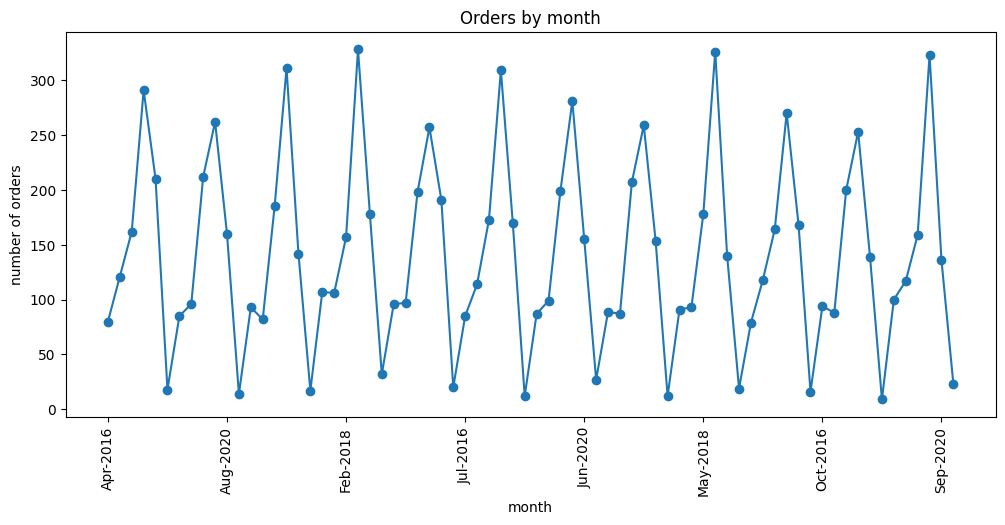

In [31]:
# monthly order trend, only for rows that have a valid date
monthly = df[df['has_order_date']].groupby('order_month')['order_id'].nunique().sort_index()
plt.figure(figsize=(12,5))
monthly.plot(kind='line', marker='o')
plt.title('Orders by month')
plt.xlabel('month')
plt.ylabel('number of orders')
plt.xticks(rotation=90)
plt.show()

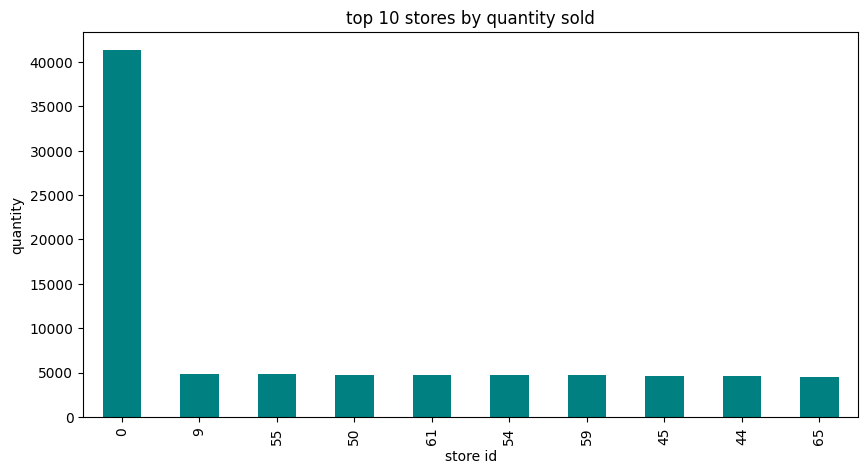

In [32]:
# quantity sold by store
plt.figure(figsize=(10,5))
df.groupby('store_id')['quantity'].sum().sort_values(ascending=False).head(10).plot(kind='bar', color='teal')
plt.title('top 10 stores by quantity sold')
plt.xlabel('store id')
plt.ylabel('quantity')
plt.show()

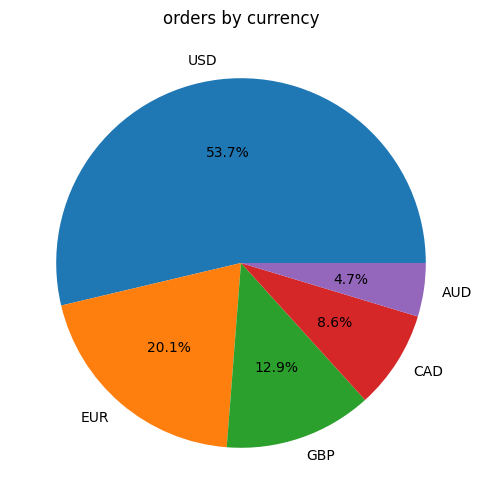

In [33]:
# currency wise order share
plt.figure(figsize=(6,6))
df['currency_code'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('orders by currency')
plt.ylabel('')
plt.show()

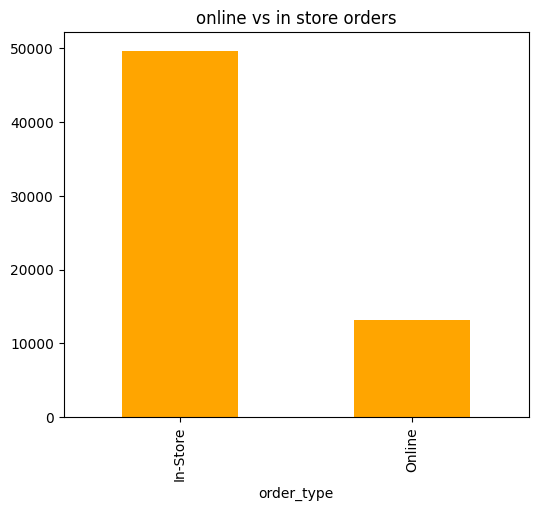

In [34]:
# online vs in store orders
plt.figure(figsize=(6,5))
df['order_type'].value_counts().plot(kind='bar', color='orange')
plt.title('online vs in store orders')
plt.show()

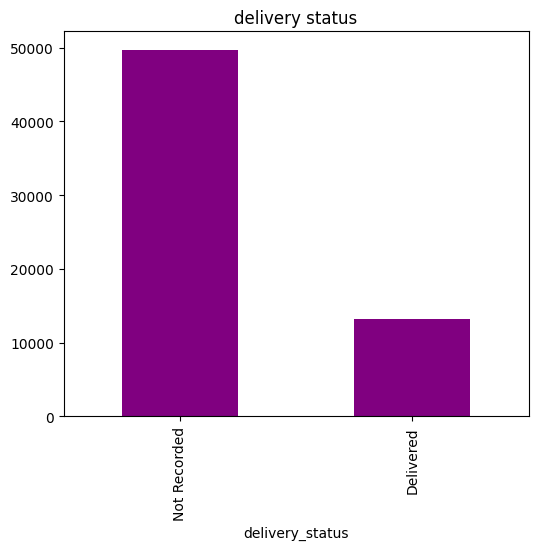

In [35]:
# delivery status split
plt.figure(figsize=(6,5))
df['delivery_status'].value_counts().plot(kind='bar', color='purple')
plt.title('delivery status')
plt.show()

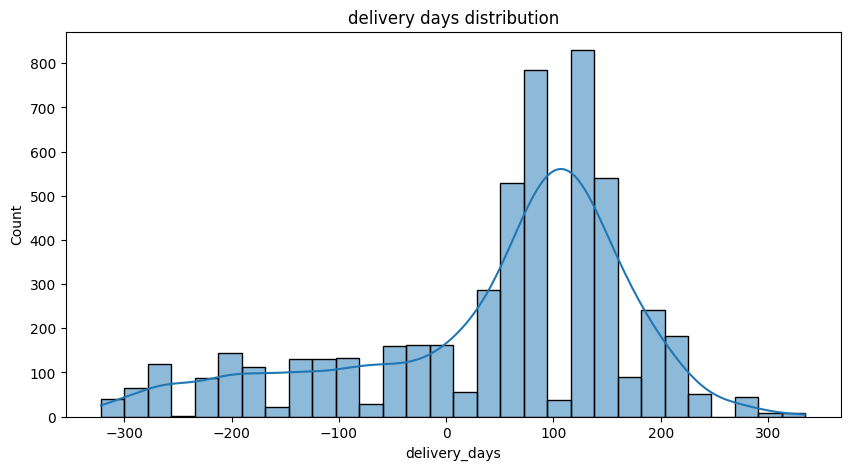

In [36]:
# distribution of delivery days for valid rows only
plt.figure(figsize=(10,5))
sns.histplot(df['delivery_days'].dropna(), bins=30, kde=True)
plt.title('delivery days distribution')
plt.show()

# **INSIGHTS**

In [37]:
# total orders and quantity
print('total orders', df['order_id'].nunique())
print('total line items', df.shape[0])
print('total quantity sold', df['quantity'].sum())

total orders 26326
total line items 62884
total quantity sold 197757


In [38]:
# missing data percentage
print('percentage of orders missing order date', round(df['order_date'].isnull().mean()*100,2))
print('percentage of orders missing delivery date', round(df['delivery_date'].isnull().mean()*100,2))

percentage of orders missing order date 61.29
percentage of orders missing delivery date 79.06


In [39]:
# store with highest quantity sold
top_store = df.groupby('store_id')['quantity'].sum().idxmax()
print('store with highest quantity sold is', top_store)

store with highest quantity sold is 0


In [40]:
# most common currency used
print('most common currency is', df['currency_code'].value_counts().idxmax())

most common currency is USD


In [41]:
# invalid delivery dates count
print('rows where delivery happened before order date', df['invalid_delivery'].sum())

rows where delivery happened before order date 1332


In [42]:
# simple summary print
print('this dataset has', df['order_id'].nunique(), 'orders and', df.shape[0], 'line items')
print(round(df['order_date'].isnull().mean()*100,2), 'percent of orders do not have an order date recorded')
print('online orders are', df[df['order_type']=='Online'].shape[0], 'and in store orders are', df[df['order_type']=='In-Store'].shape[0])
print('average delivery time is', round(df['delivery_days'].mean(),1), 'days for orders with valid dates')

this dataset has 26326 orders and 62884 line items
61.29 percent of orders do not have an order date recorded
online orders are 13165 and in store orders are 49719
average delivery time is 45.7 days for orders with valid dates
